In [ ]:
import random
import numpy as np
import pandas as pd
import librosa
import torch
import torchaudio

## Helper Functions

In [3]:
SR = 32000
DURATION = 30
N_SAMPLES = SR * DURATION

def load_audio(path):
    y, _ = librosa.load(path, sr=SR)
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    else:
        start = random.randint(0, len(y) - N_SAMPLES)
        y = y[start:start + N_SAMPLES]
    return y

In [12]:
import os
import numpy as np

def load_stems(stem_dir):
    stems = ["bass.wav", "drums.wav", "vocals.wav", "other.wav"]
    audio = np.zeros(N_SAMPLES, dtype=np.float32)

    for stem in stems:
        path = os.path.join(stem_dir, stem)

        if os.path.exists(path):
            y = load_audio(path)
            audio += y

    return normalize_audio(audio)


In [4]:
def rms(x):
    return np.sqrt(np.mean(x**2) + 1e-8)

def normalize_audio(x):
    return x / (np.max(np.abs(x)) + 1e-6)

In [5]:
def mix_same_genre(song_a, song_b):
    w1 = random.uniform(0.4, 0.6)
    w2 = 1 - w1
    mix = w1 * song_a + w2 * song_b
    return normalize_audio(mix)

In [6]:
def build_noise_track(noise_paths):
    n_events = random.randint(1, 3)
    noise_track = np.zeros(N_SAMPLES)
    for _ in range(n_events):
        noise = load_audio(random.choice(noise_paths))
        dur = random.randint(SR, 5 * SR)
        start_noise = random.randint(0, len(noise) - dur)
        noise = noise[start_noise:start_noise + dur]
        start = random.randint(0, N_SAMPLES - dur)
        gain = random.uniform(0.2, 0.8)
        noise_track[start:start + dur] += gain * noise
    return normalize_audio(noise_track)

In [7]:
def apply_snr(signal, noise):
    snr_db = random.choice([
        random.uniform(20, 30),
        random.uniform(10, 20),
        random.uniform(0, 10)
    ])
    signal_rms = rms(signal)
    noise_rms = rms(noise)
    desired_noise_rms = signal_rms / (10**(snr_db / 20))
    noise = noise * (desired_noise_rms / (noise_rms + 1e-8))
    return normalize_audio(signal + noise)

## Dataset creation

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm import tqdm

TARGET_PER_SONG = 8
OUTPUT_DIR = "static_augmented_dataset/audio"
os.makedirs(OUTPUT_DIR, exist_ok=True)

metadata = pd.read_csv("/kaggle/working/stems_metadata.csv")

# Collect noise files
noise_paths = []
for root, _, files in os.walk("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio"):
    for file in files:
        if file.endswith(".wav"):
            noise_paths.append(os.path.join(root, file))

rows = []

for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):

    stem_dir = row["stem_dir"]
    genre = row["genre"]

    base_audio = load_stems(stem_dir)

    for v in range(TARGET_PER_SONG):

        y = base_audio.copy()

        n_noises = random.randint(3, 8)
        chosen_noises = random.sample(noise_paths, n_noises)

        combined_noise = np.zeros_like(y)

        for noise_path in chosen_noises:
            noise = load_audio(noise_path)

            # random start
            start = random.randint(0, len(y) - len(noise))
            gain = random.uniform(0.2, 0.7)

            combined_noise[start:start+len(noise)] += gain * noise

        y = normalize_audio(y + combined_noise)

        filename = f"{genre}_{idx}_{v}.wav"
        filepath = os.path.join(OUTPUT_DIR, filename)

        sf.write(filepath, y, SR, subtype="PCM_16")

        rows.append({
            "filepath": filepath,
            "genre": genre
        })

df = pd.DataFrame(rows)
df.to_csv("static_augmented_dataset/metadata.csv", index=False)

print("Generated", len(df), "augmented songs")


100%|██████████| 1000/1000 [16:20<00:00,  1.02it/s]

Generated 8000 augmented songs


### Converting Audio files to Spectograms

In [ ]:
import os
import numpy as np
import librosa
import pandas as pd
from PIL import Image
from tqdm import tqdm

AUDIO_DIR = "/kaggle/input/datasets/sreekaranreddy2005/dlgenai-proj-audio-classification/messy-mashup-augmented/audio"
OUTPUT_DIR = "mel_spectrograms"
CSV_PATH = "mel_labels.csv"

SR = 22050
DURATION = 5
SAMPLES = SR * DURATION
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

os.makedirs(OUTPUT_DIR, exist_ok=True)

records = []

def pad_truncate(signal):
    if len(signal) > SAMPLES:
        return signal[:SAMPLES]
    else:
        return np.pad(signal, (0, SAMPLES - len(signal)))

for root, _, files in os.walk(AUDIO_DIR):
    label = os.path.basename(root)
    for file in tqdm(files):
        if file.lower().endswith(".wav"):
            path = os.path.join(root, file)

            try:
                signal, _ = librosa.load(path, sr=SR)
                signal = pad_truncate(signal)

                mel = librosa.feature.melspectrogram(
                    y=signal,
                    sr=SR,
                    n_fft=N_FFT,
                    hop_length=HOP_LENGTH,
                    n_mels=N_MELS
                )

                mel_db = librosa.power_to_db(mel, ref=np.max)

                mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min())
                mel_img = (mel_norm * 255).astype(np.uint8)

                img = Image.fromarray(mel_img)
                img = img.transpose(Image.FLIP_TOP_BOTTOM)

                out_name = file.rsplit(".", 1)[0] + ".png"
                out_path = os.path.join(OUTPUT_DIR, out_name)
                img.save(out_path)

                records.append([out_name, label])

            except Exception as e:
                print("Error:", path, e)

df = pd.DataFrame(records, columns=["image", "label"])
df.to_csv(CSV_PATH, index=False)


 95%|█████████▌| 9546/10000 [12:00<00:32, 14.02it/s]

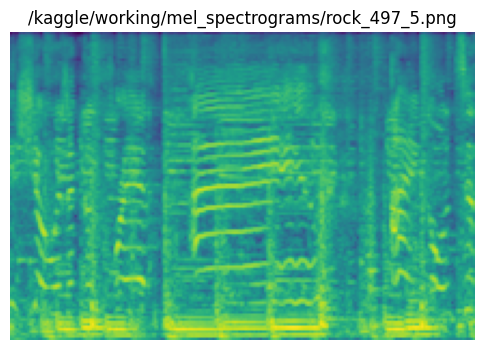

In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = "/kaggle/working/mel_spectrograms"

files = [f for f in os.listdir(IMG_DIR) if f.endswith(".png")]
img_path = os.path.join(IMG_DIR, random.choice(files))

img = Image.open(img_path)

plt.figure(figsize=(6,4))
plt.imshow(img, aspect='auto')
plt.title(img_path)
plt.axis("off")
plt.show()


Creating a csv file which contains the genre of all the audio files in the given dataset

In [10]:
import os
import pandas as pd

root = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
rows = []

for genre in os.listdir(root):
    genre_path = os.path.join(root, genre)

    if os.path.isdir(genre_path):
        for song_folder in os.listdir(genre_path):
            stem_dir = os.path.join(genre_path, song_folder)

            if os.path.isdir(stem_dir):
                rows.append({
                    "stem_dir": stem_dir,
                    "genre": genre
                })

df = pd.DataFrame(rows)
df.to_csv("stems_metadata.csv", index=False)

print("Saved stems_metadata.csv with", len(df), "entries")


Saved stems_metadata.csv with 1000 entries
